In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load the main datasets
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Customers: (99441, 5)
Reviews: (99224, 7)
Products: (32951, 9)


In [53]:
import sys
print(sys.path)

['c:\\Users\\Nikhil\\AppData\\Local\\Python\\pythoncore-3.12-64\\python312.zip', 'c:\\Users\\Nikhil\\AppData\\Local\\Python\\pythoncore-3.12-64\\DLLs', 'c:\\Users\\Nikhil\\AppData\\Local\\Python\\pythoncore-3.12-64\\Lib', 'c:\\Users\\Nikhil\\AppData\\Local\\Python\\pythoncore-3.12-64', '', 'C:\\Users\\Nikhil\\AppData\\Roaming\\Python\\Python312\\site-packages', 'c:\\Users\\Nikhil\\AppData\\Local\\Python\\pythoncore-3.12-64\\Lib\\site-packages']


In [54]:
import pandas
print(pandas.__file__)
print(pandas.__version__)

c:\Users\Nikhil\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\pandas\__init__.py
3.0.3


In [55]:
print("=== ORDERS ===")
print(orders.columns.tolist())
#print(orders.head(2))

print("\n=== ORDER ITEMS ===")
print(order_items.columns.tolist())
#print(order_items.head(2))

print("\n=== CUSTOMERS ===")
print(customers.columns.tolist())
#print(customers.head(2))

print("\n=== REVIEWS ===")
print(reviews.columns.tolist())
#print(reviews.head(2))

print("\n=== PRODUCTS ===")
print(products.columns.tolist())
#print(products.head(2))

=== ORDERS ===
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

=== ORDER ITEMS ===
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

=== CUSTOMERS ===
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

=== REVIEWS ===
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

=== PRODUCTS ===
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [56]:
print("=== MISSING VALUES ===")
print("\nOrders:")
print(orders.isnull().sum())

print("\nOrder Items:")
print(order_items.isnull().sum())

print("\nCustomers:")
print(customers.isnull().sum())

print("\nReviews:")
print(reviews.isnull().sum())

print("\nProducts:")
print(products.isnull().sum())

=== MISSING VALUES ===

Orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order Items:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Customers:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Reviews:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Products:
product_i

In [57]:
# Merge order items with orders
df = order_items.merge(orders, on='order_id', how='left')

# Only keep delivered orders
df = df[df['order_status'] == 'delivered']

# Calculate AOV — total spend per order
aov_df = df.groupby('order_id').agg(
    order_value=('price', 'sum'),
    freight_value=('freight_value', 'sum')
).reset_index()

aov_df['total_order_value'] = aov_df['order_value'] + aov_df['freight_value']

print("Total delivered orders:", len(aov_df))
print("\nAOV Statistics:")
print(aov_df['total_order_value'].describe())

Total delivered orders: 96478

AOV Statistics:
count    96478.000000
mean       159.826839
std        218.794219
min          9.590000
25%         61.850000
50%        105.280000
75%        176.260000
max      13664.080000
Name: total_order_value, dtype: float64


In [58]:
# Merge order items with orders
df1 = order_items.merge(orders, on='order_id', how='left')
df = df1.merge(products, on = 'product_id', how = 'left')
# Only keep delivered orders
df = df[df['order_status'] == 'delivered']

# Calculate AOV — total spend per order
aov_df = df.groupby('product_category_name').agg(
    order_value=('price', 'mean'),
    freight_value=('freight_value', 'mean')
).reset_index()
aov_df['total_order_value'] = aov_df['order_value'] + aov_df['freight_value']
aov_df['category'] = aov_df['total_order_value']
aov_sorted = (aov_df[['product_category_name','total_order_value']]).sort_values('total_order_value', ascending = False)
print("Total delivered orders:", len(aov_df))
print((aov_df[['product_category_name','total_order_value']]).sort_values('total_order_value'))
print(aov_df['total_order_value'].head(10))
print(aov_df['total_order_value'].tail(10))


Total delivered orders: 73
          product_category_name  total_order_value
15              casa_conforto_2          39.019333
41                       flores          48.451818
42              fraldas_higiene          55.302432
17            cds_dvds_musicais          68.213571
36       fashion_roupa_feminina          71.520889
..                          ...                ...
45        instrumentos_musicais         310.579293
0     agro_industria_e_comercio         369.918932
29           eletrodomesticos_2         511.725195
64  portateis_casa_forno_e_cafe         674.601370
61                          pcs        1147.486231

[73 rows x 2 columns]
0    369.918932
1     71.732826
2     71.887621
3    139.520457
4     91.005833
5    125.842381
6     79.525000
7    155.401436
8    161.704046
9    156.514973
Name: total_order_value, dtype: float64
63    130.256861
64    674.601370
65    302.003571
66    215.793330
67    162.255000
68    141.079137
69    105.477229
70     85.598786
71

TypeError: 'str' object is not callable

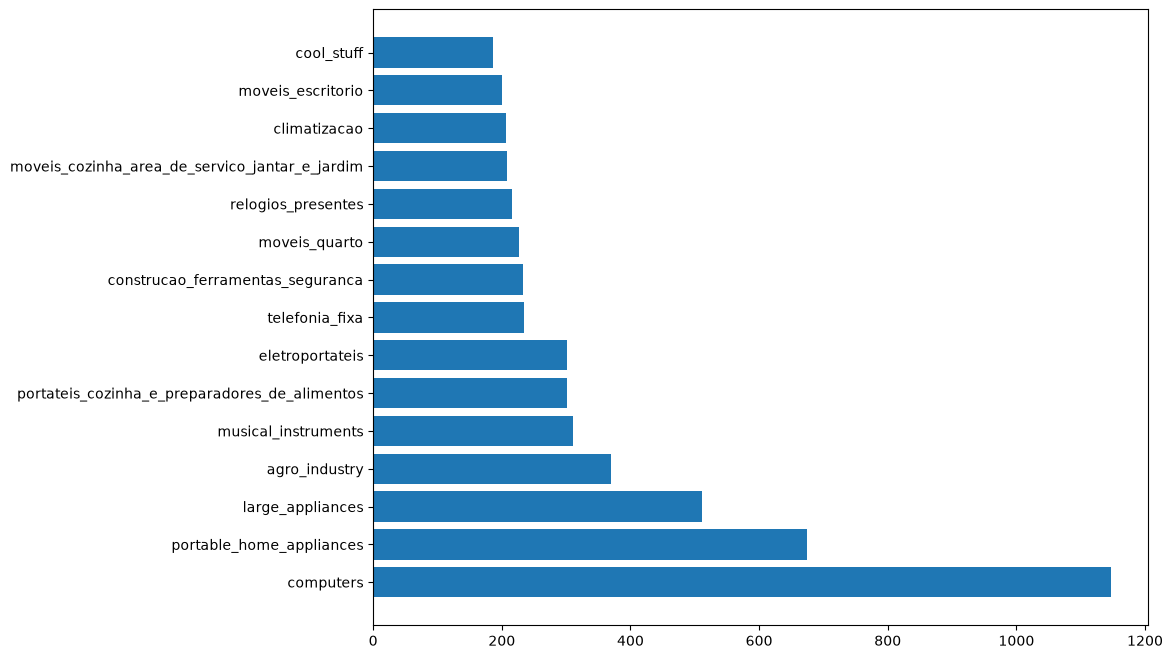

In [59]:
translation = {
    'pcs': 'computers',
    'portateis_casa_forno_e_cafe': 'portable_home_appliances',
    'eletrodomesticos_2': 'large_appliances',
    'agro_industria_e_comercio': 'agro_industry',
    'instrumentos_musicais': 'musical_instruments',
    'fashion_roupa_feminina': 'womens_fashion',
    'cds_dvds_musicais': 'cds_dvds',
    'fraldas_higiene': 'diapers_hygiene',
    'flores': 'flowers',
    'casa_conforto_2': 'home_comfort'
}

aov_sorted['category_english'] = aov_sorted['product_category_name'].map(translation).fillna(aov_sorted['product_category_name'])

plt.figure(figsize=(10, 8))
plt.barh(
    aov_sorted.head(15)['category_english'],
    aov_sorted.head(15)['total_order_value']
)
plt.xlabel('Average Order Value (R$)')
plt.title('Top 15 Product Categories by AOV')
plt.tight_layout()
plt.show()

Insight:
Electronics and computer categories dominate AOV, with computers averaging R$1,147 — nearly 6x higher than furniture and home categories. This suggests prioritizing stock availability and seller acquisition in high-AOV categories to maximize revenue per order. Low AOV categories like furniture and home comfort may benefit from bundling strategies or targeted promotions to increase basket size.

Question-2

In [ ]:
# Convert date columns to datetime format
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Calculate delivery delay in days
# Positive = late, Negative = early
orders['delivery_delay'] = (
    orders['order_delivered_customer_date'] - 
    orders['order_estimated_delivery_date']
).dt.days

# Calculate actual delivery time from purchase to delivery
orders['actual_delivery_days'] = (
    orders['order_delivered_customer_date'] - 
    orders['order_purchase_timestamp']
).dt.days

print(orders[['delivery_delay', 'actual_delivery_days']].describe())

       delivery_delay  actual_delivery_days
count    96476.000000          96476.000000
mean       -11.876881             12.094086
std         10.183854              9.551746
min       -147.000000              0.000000
25%        -17.000000              6.000000
50%        -12.000000             10.000000
75%         -7.000000             15.000000
max        188.000000            209.000000


In [ ]:
# Merge order items with orders
df = orders.merge(reviews, on='order_id', how='left')

# Only keep delivered orders
df = df[df['order_status'] == 'delivered']

# Calculate AOV — total spend per order

df['delivery_status'] = df['delivery_delay'].apply(lambda x: 'late' if x>0 else 'early'  )

aov_df = df.groupby('delivery_status').agg(
    review=('review_score', 'mean')
).reset_index()
aov_df['average_review'] = aov_df['review']

print("\nAOV Statistics:")
print(aov_df['average_review'].describe())
print(aov_df[['delivery_status', 'average_review']])


AOV Statistics:
count    2.000000
mean     3.280512
std      1.427630
min      2.271025
25%      2.775769
50%      3.280512
75%      3.785256
max      4.289999
Name: average_review, dtype: float64
  delivery_status  average_review
0           early        4.289999
1            late        2.271025


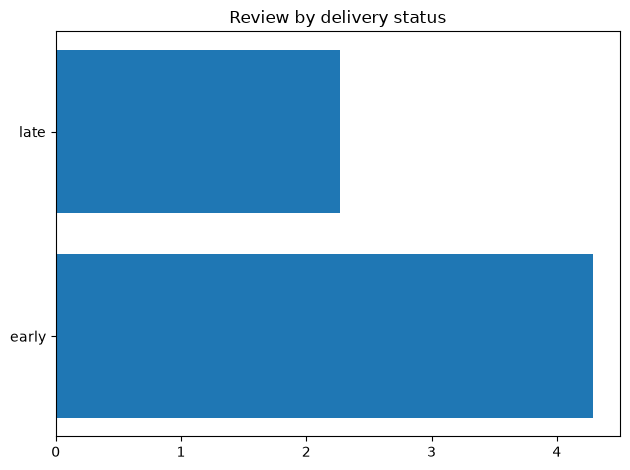

In [ ]:

plt.barh(
    aov_df['delivery_status'],
    aov_df['average_review']
)
plt.xlabel("Delivery Status")
plt.ylabel("Average Review")
plt.title('Review by delivery status')
plt.tight_layout()
plt.show()

In [ ]:
df = order_items.merge(orders,on = 'order_id', how = 'left')
df2 = df.merge(reviews, on='order_id', how = 'left')

df2 = df2[df2['order_status'] == 'delivered']

rev_df = df2.groupby('seller_id').agg(
    revenue = ('price','sum'),
    orders = ('order_id','count'),
    seller_ratings = ('review_score', 'mean')
).reset_index()
rev_df_sorted = (rev_df[['revenue','orders','seller_ratings']].sort_values('revenue', ascending = False))
print(rev_df_sorted[['revenue','orders','seller_ratings']].head(10))
print(rev_df_sorted[['revenue','orders','seller_ratings']].tail(10))

        revenue  orders  seller_ratings
834   226987.93    1148        4.139474
982   217940.44     400        4.128141
858   199408.32    1971        3.828630
2903  190917.14     579        4.373913
1480  188063.83    1366        3.354197
1504  165981.49     322        4.364486
2543  162303.67    1571        4.075399
1450  140238.65    1159        4.268462
188   139720.16    1434        3.867792
1758  131906.71    1474        4.089481
      revenue  orders  seller_ratings
2900    11.20       1             5.0
606     10.90       1             2.0
1762     9.99       1             5.0
2247     9.90       1             5.0
181      9.00       1             5.0
846      8.49       1             5.0
2007     8.25       1             5.0
1319     7.60       1             5.0
363      6.90       1             1.0
1414     6.50       1             5.0


Insight:
"Top sellers by revenue generate high order volumes (700-1900 orders) with consistently good ratings around 3.8-4.4, while low revenue sellers have only 1-2 orders with perfect 5.0 ratings — likely due to insufficient review volume to reflect true quality. Business should prioritize stock availability and logistics support for high revenue sellers as they drive majority of platform GMV. Low revenue single-order sellers should not be over-indexed on rating alone."

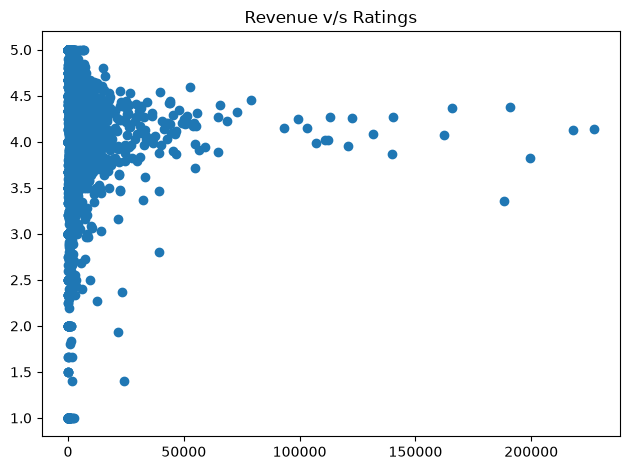

In [ ]:
plt.scatter(
    rev_df_sorted['revenue'],
    rev_df_sorted['seller_ratings']
)
plt.xlabel('Revenue')
plt.ylabel('Seller_ratings')
plt.title('Revenue v/s Ratings')
plt.tight_layout()
plt.show()

In [ ]:
df = orders.merge(customers, on = 'customer_id', how = 'left')
df = df[df['order_status'] == 'delivered']

aov_df = df.groupby('customer_unique_id').agg(
    order_count = ('order_id','count')
).reset_index()
aov_df['customer_type'] = aov_df['order_count'].apply(lambda x: 'repeat' if x > 1 else 'one time' )


df1 = aov_df.merge(df, on= 'customer_unique_id', how = 'left')
df2 = df1.merge(order_items, on = 'order_id', how = 'left')
df3 = df2.merge(products, on = 'product_id', how = 'left')
repeat_df = df3[df3['customer_type'] == 'repeat']
print(repeat_df['product_category_name'].value_counts().head(10))
df_sorted = repeat_df[['product_category_name', 'customer_type', 'order_count']].sort_values('order_count', ascending = False)
print(df_sorted[['product_category_name', 'customer_type', 'order_count']].head(10))

product_category_name
cama_mesa_banho                1073
moveis_decoracao                798
esporte_lazer                   640
beleza_saude                    529
informatica_acessorios          528
utilidades_domesticas           413
relogios_presentes              312
fashion_bolsas_e_acessorios     251
ferramentas_jardim              241
telefonia                       223
Name: count, dtype: int64
             product_category_name customer_type  order_count
60608                esporte_lazer        repeat           15
60613                esporte_lazer        repeat           15
60607                esporte_lazer        repeat           15
60612  fashion_bolsas_e_acessorios        repeat           15
60615                esporte_lazer        repeat           15
60616                esporte_lazer        repeat           15
60617                esporte_lazer        repeat           15
60618  fashion_bolsas_e_acessorios        repeat           15
60611                esporte_lazer

Insight:

"There's a clear inverse relationship between AOV and repeat purchase behavior. High-AOV categories like computers, large appliances, and furniture drive significant one-time revenue but see almost no repeat purchases — consistent with their durable, infrequent-replacement nature. In contrast, lower-AOV categories like home linens (cama_mesa_banho), beauty/health, and sports/leisure show the highest repeat purchase volume, suggesting these are Olist's true retention drivers. This implies a dual strategy: use high-AOV categories to maximize one-time order value, while investing retention efforts — loyalty programs, personalized recommendations, subscription bundles — specifically in low-AOV, high-frequency categories where repeat behavior is naturally higher."

TypeError: 'str' object is not callable

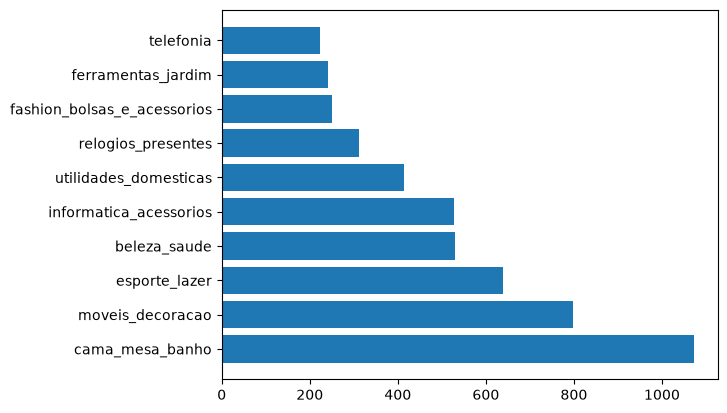

In [60]:
category_counts = df_sorted['product_category_name'].value_counts().head(10)
plt.barh(
    category_counts.index,
    category_counts.values
)
plt.xlabel('number of orders')
plt.ylabel('category')
plt.tight_layout()
plt.show()
